In [1]:

import contextily as ctx
import geopandas as gpd
import rioxarray as rio

import matplotlib.pyplot as plt

from pathlib import Path
from rioxarray.raster_array import RasterArray
import rioxarray as rio
import xarray as xr
import numpy as np
from rioxarray.merge import merge_arrays
import numpy as np
import rasterio
import xgboost as xgb
import cv2
import geopandas as gpd
from pystac_client import Client
from odc.stac import load

from shapely.geometry import box
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

import rioxarray as rio

from download.setup.constants import Paths

mariupol = gpd.read_file(
    Paths.RAW_DATA_DIR
    / "geospatial"
    / "mariupol_2022.geojson",
    use_arrow=True,
    where="Main_Damag <= 3"
).to_crs(32637)

mariupol_convex = mariupol.dissolve().convex_hull

# mariupol.plot()

bbox = tuple(map(float, mariupol.total_bounds))

ax = mariupol_convex.plot()
mariupol.plot(ax=ax, color="red")


ModuleNotFoundError: No module named 'xgboost'

In [230]:


Path(Paths.RAW_DATA_DIR / "earth_observation" / "20230503")

PosixPath('data/raw/earth_observation/20230503')

In [ ]:
def create_rgb_raster(red_file: str, green_file: str, blue_file: str) -> xr.DataArray:
    """
    Create an RGB raster by combining individual red, green, and blue rasters.

    :param red_file: File path to the red band raster.
    :param green_file: File path to the green band raster.
    :param blue_file: File path to the blue band raster.
    :return: Combined RGB raster (xarray DataArray).
    """

    # Open each band raster
    red = rio.open_rasterio(red_file, band=1)  # Red band
    green = rio.open_rasterio(green_file, band=1)  # Green band
    blue = rio.open_rasterio(blue_file, band=1)  # Blue band

    # Stack the rasters along a new dimension ('band')
    rgb_raster = xr.concat([red, green, blue], dim="band")

    return rgb_raster


def rgb_to_opencv(rgb_raster: xr.DataArray) -> np.ndarray:
    """
    Convert a three-band raster to a NumPy array for OpenCV.

    :param rgb_raster: The combined RGB raster (xarray DataArray).
    :return: RGB image as a NumPy array.
    """

    # Convert the xarray DataArray to a NumPy array (shape: [bands, height, width])
    rgb_array = rgb_raster.values

    # Convert the bands dimension to the last axis (height, width, bands) for OpenCV
    rgb_image = np.moveaxis(rgb_array, 0, -1)

    # Ensure the data type is uint8 (required for OpenCV)
    rgb_image = np.clip(rgb_image, 0, 255).astype(np.uint8)

    return rgb_image



In [ ]:
def data_prep(folder: Path) -> None:
    # set destination folder
    dest_folder = Paths.PROCESSED_DATA_DIR / folder.name
    dest_folder.mkdir(parents=True, exist_ok=True)

    # list files to process
    files = list(folder).glob(f"*.tif")

    # clip values to Mariupol
    for file in files:
        filename = file.stem.split("_")[-1] + ".tif"
        raster = rio.open_rasterio(file, chunks=True, lock=False)
        clipped = RasterArray(
            raster.rio.clip(mariupol_convex.geometry, all_touched=True)
        )
        clipped.to_raster(dest_folder / filename)

    rgb_raster = create_rgb_raster(
        dest_folder / "red.tif",
        dest_folder / "green.tif",
        dest_folder / "blue.tif",
    )

    rgb_np = rgb_to_opencv(rgb_raster)

In [233]:
items[0]

<Item id=S2B_37TCN_20230518_0_L2A>

In [145]:
files = list(Path(Paths.RAW_DATA_DIR / "earth_observation").glob(f"*.tif"))

crs_val = rio.open_rasterio(files[0]).rio.crs
mariupol_convex = mariupol_convex.to_crs(crs_val)
mariupol = mariupol.to_crs(crs_val)

for file in files:
    filename = file.stem.split("_")[-1] + ".tif"
    raster = rio.open_rasterio(file, chunks=True, lock=False)
    clipped = RasterArray(raster.rio.clip(mariupol_convex.geometry, all_touched=True))
    clipped.to_raster(Paths.RAW_DATA_DIR / filename)

    



In [22]:
def create_rgb_raster(red_file: str, green_file: str, blue_file: str) -> xr.DataArray:
    """
    Create an RGB raster by combining individual red, green, and blue rasters.

    :param red_file: File path to the red band raster.
    :param green_file: File path to the green band raster.
    :param blue_file: File path to the blue band raster.
    :return: Combined RGB raster (xarray DataArray).
    """

    # Open each band raster
    red = rio.open_rasterio(red_file, band=1)  # Red band
    green = rio.open_rasterio(green_file, band=1)  # Green band
    blue = rio.open_rasterio(blue_file, band=1)  # Blue band

    # Stack the rasters along a new dimension ('band')
    rgb_raster = xr.concat([red, green, blue], dim="band")

    return rgb_raster


def rgb_to_opencv(rgb_raster: xr.DataArray) -> np.ndarray:
    """
    Convert a three-band raster to a NumPy array for OpenCV.

    :param rgb_raster: The combined RGB raster (xarray DataArray).
    :return: RGB image as a NumPy array.
    """

    # Convert the xarray DataArray to a NumPy array (shape: [bands, height, width])
    rgb_array = rgb_raster.values

    # Convert the bands dimension to the last axis (height, width, bands) for OpenCV
    rgb_image = np.moveaxis(rgb_array, 0, -1)

    # Ensure the data type is uint8 (required for OpenCV)
    rgb_image = np.clip(rgb_image, 0, 255).astype(np.uint8)

    return rgb_image

# rgb_raster = create_rgb_raster(
#     Paths.RAW_DATA_DIR / "red.tif",
#     Paths.RAW_DATA_DIR / "green.tif",
#     Paths.RAW_DATA_DIR / "blue.tif",
# )

# rgb_np = rgb_to_opencv(rgb_raster)

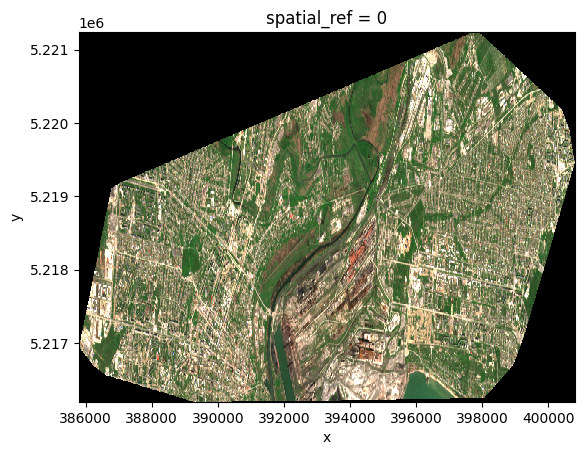

In [217]:
rgb_raster.plot.imshow(robust=True)

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='x', ylabel='y'>

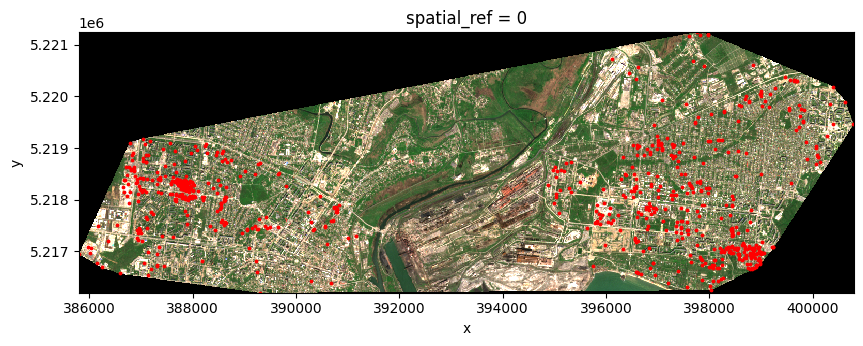

In [147]:
fig, ax = plt.subplots(figsize=(10, 10))
rgb_raster.plot.imshow(robust=True, ax=ax)
mariupol.plot(ax=ax, color="red", markersize=3)

In [204]:
from rioxarray.raster_dataset import RasterDataset

red = rio.open_rasterio(Paths.RAW_DATA_DIR / "red.tif", chunks=True, lock=False).astype(
    "float"
)

nir = rio.open_rasterio(Paths.RAW_DATA_DIR / "nir.tif", chunks=True, lock=False).astype(
    "float"
)

ndvi = (nir.astype(float) - red.astype(float)) / (nir + red)

ndvi.rio.write_crs(crs_val).rio.to_raster(Paths.RAW_DATA_DIR / "ndvi.tif")


In [11]:
import json
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Union

import dask
import numpy as np
import planetary_computer
import pystac
import pystac_client
import rasterio.features
import rioxarray as rio
import stackstac
import xarray as xr
from dask.distributed import Client
from dask_gateway import GatewayCluster
from pydantic import BaseModel, HttpUrl

import dask
import dask.array as da
import functools
import numpy as np
import xarray as xr
from typing import Optional, Tuple, Union
from random import randint

from dask.delayed import Delayed

import distributed

from download.setup.constants import Paths

def get_total_available_memory(check_jupyter_hub=True):
    """Figure out how much memory is available.

    1. Check MEM_LIMIT environment variable, set by jupyterhub
    2. Use hardware information if that not set
    """
    if check_jupyter_hub:
        mem_limit = os.environ.get("MEM_LIMIT", None)
        if mem_limit is not None:
            return int(mem_limit)

    from psutil import virtual_memory

    return virtual_memory().total


def compute_memory_per_worker(
    n_workers: int = 1,
    mem_safety_margin: Optional[Union[str, int]] = None,
    memory_limit: Optional[Union[str, int]] = None,
) -> int:
    """Figure out how much memory to assign per worker.

    result can be passed into ``memory_limit=`` parameter of dask worker/cluster/client
    """
    from dask.utils import parse_bytes

    if isinstance(memory_limit, str):
        memory_limit = parse_bytes(memory_limit)

    if isinstance(mem_safety_margin, str):
        mem_safety_margin = parse_bytes(mem_safety_margin)

    if memory_limit is None and mem_safety_margin is None:
        total_bytes = get_total_available_memory()
        # leave 500Mb or half of all memory if RAM is less than 1 Gb
        mem_safety_margin = min(500 * (1024 * 1024), total_bytes // 2)
    elif memory_limit is None:
        total_bytes = get_total_available_memory()
    elif mem_safety_margin is None:
        total_bytes = memory_limit
        mem_safety_margin = 0
    else:
        total_bytes = memory_limit

    return (total_bytes - mem_safety_margin) // n_workers


def start_local_dask(
    n_workers: int = 1,
    threads_per_worker: Optional[int] = None,
    mem_safety_margin: Optional[Union[str, int]] = None,
    memory_limit: Optional[Union[str, int]] = None,
    **kw,
):
    """Wrapper around ``distributed.Client(..)`` constructor that deals with memory better.

    It also configures ``distributed.dashboard.link`` to go over proxy when operating
    from behind jupyterhub.

    :param n_workers: number of worker processes to launch
    :param threads_per_worker: number of threads per worker, default is as many as there are CPUs
    :param memory_limit: maximum memory to use across all workers
    :param mem_safety_margin: bytes to reserve for the rest of the system, only applicable
                              if ``memory_limit=`` is not supplied.

    .. note::

        if ``memory_limit=`` is supplied, it will be parsed and divided equally between workers.
    """
    # if dashboard.link set to default value and running behind hub, make dashboard link go via proxy
    if (
        dask.config.get("distributed.dashboard.link")
        == "{scheme}://{host}:{port}/status"
    ):
        jup_prefix = os.environ.get("JUPYTERHUB_SERVICE_PREFIX")
        if jup_prefix is not None:
            jup_prefix = jup_prefix.rstrip("/")
            dask.config.set(
                {"distributed.dashboard.link": f"{jup_prefix}/proxy/{{port}}/status"}
            )

    memory_limit = compute_memory_per_worker(
        n_workers=n_workers,
        memory_limit=memory_limit,
        mem_safety_margin=mem_safety_margin,
    )

    client = Client(
        n_workers=n_workers,
        threads_per_worker=threads_per_worker,
        memory_limit=memory_limit,
        **kw,
    )

    return client

# client = start_local_dask()
client = start_local_dask(n_workers=4, mem_safety_margin="1GB")

# client.shutdown()

2025-03-17 10:08:05,632 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:59844' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('where-aa9112407cccec6638ad387f52059a35', 10, 0, 0, 0), ('where-7bbeaada23869e2e981a3a5df9745a34', 39, 2, 0, 0), ('where-aa9112407cccec6638ad387f52059a35', 42, 1, 0, 0), ('where-7bbeaada23869e2e981a3a5df9745a34', 10, 1, 0, 0), ('where-aa9112407cccec6638ad387f52059a35', 27, 0, 0, 0), ('where-7bbeaada23869e2e981a3a5df9745a34', 15, 2, 0, 0), ('asset_table_to_reader_and_window-e47d3cdb9e8bf924a76a2d0c1d90921d', 44, 1), ('where-7bbeaada23869e2e981a3a5df9745a34', 27, 2, 0, 0), ('where-7bbeaada23869e2e981a3a5df9745a34', 38, 0, 0, 0), ('where-7bbeaada23869e2e981a3a5df9745a34', 12, 2, 0, 0), ('where-aa9112407cccec6638ad387f52059a35', 24, 0, 0, 0), ('where-7bbeaada23869e2e981a3a5df9745a34', 38, 1, 0, 0), ('where-aa9112407cccec6638ad387f52059a35', 26, 1, 0, 0), ('where-aa9112407cccec6638ad387f52059a35', 15, 1

In [26]:
import geopandas as gpd

crs_val = 32630

# gmca = gpd.read_parquet(
#     Paths.RAW_DATA_DIR / "boundaries" / "geom-cauth-codes_2022.parquet",
#     filters=[("CAUTH22CD", "=", "E47000001")],
# )

london = gpd.read_parquet(
    Paths.RAW_DATA_DIR / "boundaries" / "geom-region-codes_2022.parquet",
    filters=[("RGN22CD", "=", "E12000007")],
)

In [27]:
# gmca bbox
# bbox = tuple(map(float, gmca.total_bounds))
# gmca = gmca.to_crs(crs_val)

bbox = tuple(map(float, london.total_bounds))
london = london.to_crs(crs_val)
bbox
# manchester ring road bbox
# bbox = (-2.379044, 53.395387, -2.111618, 53.554553)

(-0.510355887089289, 51.2867586581741, 0.334044062088371, 51.6918770231681)

In [15]:
stac_client = pystac_client.Client.open(
    url="https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [37]:
# Perform STAC search with custom query
search = stac_client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2021-01-01/2021-12-31",
    query={"eo:cloud_cover": {"lt": 1}},  # Pass the custom query directly
)

items = search.item_collection()
print(f"Number of files: {len(items)}")

Number of files: 35


In [22]:

gdf = gpd.read_parquet(
    Paths.RAW_DATA_DIR / "boundaries" / "geom-region-codes_2022.parquet",
    filters=[("RGN22CD", "=", "E12000007")],
)

gdf.total_bounds

array([-0.51035589, 51.28675866,  0.33404406, 51.69187702])

In [36]:
gdf = gpd.read_parquet(
    Paths.RAW_DATA_DIR / "boundaries" / "geom-region-codes_2022.parquet",
    filters=[("RGN22CD", "=", "E12000007")],
).to_crs(crs_val)

stac_client = pystac_client.Client.open(
    url=str("https://planetarycomputer.microsoft.com/api/stac/v1"),
    modifier=planetary_computer.sign_inplace,
)

search = stac_client.search(
    collections=["sentinel-2-l2a"],
    bbox=[-0.510355887089289, 51.2867586581741, 0.334044062088371, 51.6918770231681],
    datetime="2021-01-01/2021-12-31",
    query={"eo:cloud_cover": {"lt": 1}},
)

items = search.item_collection()

data = (
    stackstac.stack(
        items,
        assets=["B04", "B03", "B02"],
        chunksize=2048,
        resolution=100,
        epsg=crs_val,
    )
    .rio.clip(gdf.geometry.buffer(1000), all_touched=True)
    .where(lambda x: x > 0, other=np.nan)  # sentinel-2 uses 0 as nodata
    .assign_coords(band=lambda x: x.common_name.rename("band"))
)

In [24]:
data = (
        stackstac.stack(
            items,
            assets=["B11", "B12"], chunksize=2048, resolution=200, epsg=crs_val
        )
        .rio.clip(london.geometry.buffer(1000), all_touched=True)
        .where(lambda x: x > 0, other=np.nan)  # sentinel-2 uses 0 as nodata
        .assign_coords(band=lambda x: x.common_name.rename("band"))  # use common names
    )


In [17]:
swir = (
    stackstac.stack(
        items, assets=["B11", "B12"], chunksize=2048, resolution=200, epsg=crs_val
    )
    .rio.clip(london.geometry.buffer(1000), all_touched=True)
    .where(lambda x: x > 0, other=np.nan)  # sentinel-2 uses 0 as nodata
    .assign_coords(band=lambda x: x.common_name.rename("band"))  # use common names
)

rgb = (
    stackstac.stack(
        items,
        assets=["B04", "B03", "B02"],  # red, green, blue
        chunksize=2048,
        resolution=100,
        epsg=crs_val,
    )
    .rio.clip(london.geometry.buffer(1000), all_touched=True)
    .where(lambda x: x > 0, other=np.nan)
    .assign_coords(band=lambda x: x.common_name.rename("band"))
)

swir = swir.persist()

rgb = rgb.persist()

In [ ]:
median_rgb_2017 = rgb.median(dim="time").compute()
median_swir_2017 = swir.median(dim="time").compute()

2025-03-12 12:08:40,096 - distributed.worker - ERROR - Compute Failed
Key:       ('getitem-where-2144b41dac28c93319e27848aa260d94', 22, 2, 0, 0)
State:     executing
Task:  <Task ('getitem-where-2144b41dac28c93319e27848aa260d94', 22, 2, 0, 0) _execute_subgraph(...)>
Exception: 'RuntimeError("Error reading Window(col_off=0, row_off=0, width=2048, height=2048) from \'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/31/U/CS/2023/11/17/S2A_MSIL2A_20231117T111331_N0509_R137_T31UCS_20231117T161144.SAFE/GRANULE/L2A_T31UCS_A043892_20231117T111332/IMG_DATA/R10m/T31UCS_20231117T111331_B02_10m.tif?st=2025-03-11T11%3A23%3A39Z&se=2025-03-12T12%3A08%3A39Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-03-12T07%3A57%3A50Z&ske=2025-03-19T07%3A57%3A50Z&sks=b&skv=2024-05-04&sig=OHke/noWt/pBArAc21g%2BeIKzWv/DWVUhwINX/5KZSVA%3D\': RasterioIOError(\'Read failed. See previous exception for details.\')")'
Traceback: '  File "/U

RuntimeError: Error reading Window(col_off=0, row_off=0, width=2048, height=2048) from 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/30/U/YB/2023/11/17/S2A_MSIL2A_20231117T111331_N0509_R137_T30UYB_20231117T161223.SAFE/GRANULE/L2A_T30UYB_A043892_20231117T111332/IMG_DATA/R10m/T30UYB_20231117T111331_B04_10m.tif?st=2025-03-11T11%3A23%3A39Z&se=2025-03-12T12%3A08%3A39Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-03-12T07%3A57%3A50Z&ske=2025-03-19T07%3A57%3A50Z&sks=b&skv=2024-05-04&sig=OHke/noWt/pBArAc21g%2BeIKzWv/DWVUhwINX/5KZSVA%3D': RasterioIOError('Read failed. See previous exception for details.')

2025-03-12 12:08:42,339 - distributed.worker - ERROR - Compute Failed
Key:       ('getitem-where-2144b41dac28c93319e27848aa260d94', 23, 1, 0, 0)
State:     executing
Task:  <Task ('getitem-where-2144b41dac28c93319e27848aa260d94', 23, 1, 0, 0) _execute_subgraph(...)>
Exception: 'RuntimeError("Error reading Window(col_off=0, row_off=0, width=2048, height=2048) from \'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/30/U/YC/2023/11/17/S2A_MSIL2A_20231117T111331_N0509_R137_T30UYC_20231117T161110.SAFE/GRANULE/L2A_T30UYC_A043892_20231117T111332/IMG_DATA/R10m/T30UYC_20231117T111331_B03_10m.tif?st=2025-03-11T11%3A23%3A39Z&se=2025-03-12T12%3A08%3A39Z&sp=rl&sv=2024-05-04&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-03-12T07%3A57%3A50Z&ske=2025-03-19T07%3A57%3A50Z&sks=b&skv=2024-05-04&sig=OHke/noWt/pBArAc21g%2BeIKzWv/DWVUhwINX/5KZSVA%3D\': RasterioIOError(\'Read failed. See previous exception for details.\')")'
Traceback: '  File "/U

In [ ]:
median_rgb_2017 = median_rgb_2017.rio.write_crs(crs_val)
median_swir_2017 = median_swir_2017.rio.write_crs(crs_val)

In [ ]:
median_rgb_2017 = median_rgb_2017.assign_coords(band=["red", "green", "blue"])
median_swir_2017 = median_swir_2017.assign_coords(band=["swir1", "swir2"])

median_rgb_2017.rio.to_raster("test_rgb_2015-2019.tif")
median_swir_2017.rio.to_raster("test_swir_2015-2019.tif")

In [10]:
# clipped = median_rgb_2017.rio.clip(gmca.geometry, all_touched=True)
clipped = median_rgb_2017.rio.clip(london.geometry, all_touched=True)

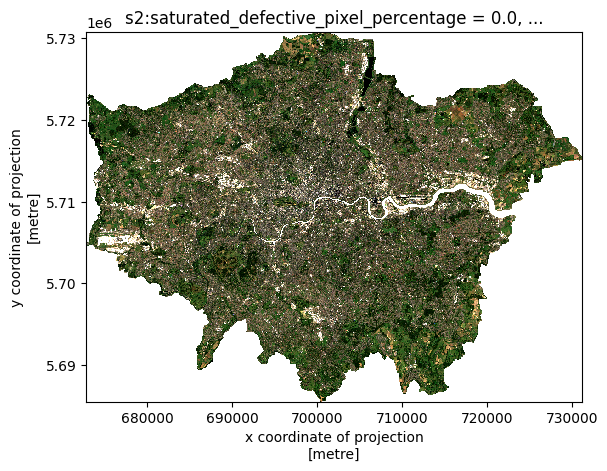

In [ ]:
clipped.plot.imshow(robust=True)

In [9]:
# Perform STAC search with custom query
search = stac_client.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2023-03-01/2023-08-31",
    query={"eo:cloud_cover": {"lt": 1}},  # Pass the custom query directly
)
items = search.item_collection()
print(f"Number of files: {len(items)}")

Number of files: 17


In [ ]:
swir = (
    stackstac.stack(
        items,
        assets=["B11", "B12"],  # red, green, blue
        chunksize=4096,
        resolution=200,
        epsg=32630
    )
    .rio.clip(london.geometry.buffer(1000), all_touched=True)
    .where(lambda x: x > 0, other=np.nan)  # sentinel-2 uses 0 as nodata
    .assign_coords(band=lambda x: x.common_name.rename("band"))  # use common names
)

rgb = (
    stackstac.stack(
        items,
        assets=["B04", "B03", "B02"],  # red, green, blue
        chunksize=4096,
        resolution=100,
        epsg=32630,
    )
    .rio.clip(london.geometry.buffer(1000), all_touched=True)
    .where(lambda x: x > 0, other=np.nan)
    .assign_coords(band=lambda x: x.common_name.rename("band"))
)

swir = swir.persist()

rgb = rgb.persist()

swir = swir.rio.clip(london.geometry.buffer(1000), all_touched=True)
rgb = rgb.rio.clip(london.geometry.buffer(1000), all_touched=True)

In [ ]:
median_rgb_2024 = rgb.median(dim="time").compute()
median_swir_2024 = swir.median(dim="time").compute()

median_rgb_2024 = median_rgb_2024.rio.write_crs(crs_val)
median_swir_2024 = median_swir_2024.rio.write_crs(crs_val)

/Users/jordanpinder/Library/Caches/pypoetry/virtualenvs/eo-basic-example-LTvdiGca-py3.10/lib/python3.10/site-packages/dask/_task_spec.py:740: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/jordanpinder/Library/Caches/pypoetry/virtualenvs/eo-basic-example-LTvdiGca-py3.10/lib/python3.10/site-packages/dask/_task_spec.py:740: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
/Users/jordanpinder/Library/Caches/pypoetry/virtualenvs/eo-basic-example-LTvdiGca-py3.10/lib/python3.10/site-packages/dask/_task_spec.py:740: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


In [ ]:
median_rgb_2024 = median_rgb_2024.assign_coords(band=["red", "green", "blue"])
median_swir_2024 = median_swir_2024.assign_coords(band=["swir1", "swir2"])

median_rgb_2024.rio.to_raster("test_rgb_2020-2024.tif")
median_swir_2024.rio.to_raster("test_swir_2020-2024.tif")

In [19]:
from dask.distributed import Lock

In [22]:
median_rgb_2024

<xarray.DataArray 'stackstac-3fab1237d2d34ef11e93c2d4d9d069a7' (band: 3,
                                                                y: 472, x: 604)> Size: 7MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(3, 472, 604))
Coordinates: (12/16)
  * x                                        (x) float64 5kB 6.719e+05 ... 7....
  * y                                        (y) float64 4kB 5.732e+06 ... 5....
    s2:saturated_defective_pixel_percentage  float64 8B 0.0
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:product_type                          <U7 28B 'S2MSI2A'
    constellation                            <U10 40B 'Sentinel 2'
    ...                                       ...
    common_name                              (band) <U5 60B 'red' 'green' 'blue'
    center_wavelength                        (band) float64 24B 0.665 0.56 0.49
    full_width_half_max                      (band) float64 24B 0.038 ... 0.098
    epsg                                     int64 8B 32630
    spatial_ref                              int64 8B 0
  * band                                     (band) <U5 60B 'red' 'green' 'blue'

In [21]:
median_rgb_2024.rio.to_raster(
        "test_rgb_2020-2024.tif",
        tiled=True,
        lock=Lock("rio"),
    )

In [11]:
# clipped_2017 = median_rgb_2017.rio.clip(gmca.geometry, all_touched=True)
# clipped_2024 = median_rgb_2024.rio.clip(gmca.geometry, all_touched=True)

clipped_2017 = median_rgb_2017.rio.clip(london.geometry, all_touched=True)
clipped_2024 = median_rgb_2024.rio.clip(london.geometry, all_touched=True)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(30, 10))

clipped_2017.plot.imshow(ax=axes[0], robust=True)
clipped_2024.plot.imshow(ax=axes[1], robust=True)

axes[0].set_title("2017")
axes[1].set_title("2024")

NameError: name 'median_rgb_2017' is not defined

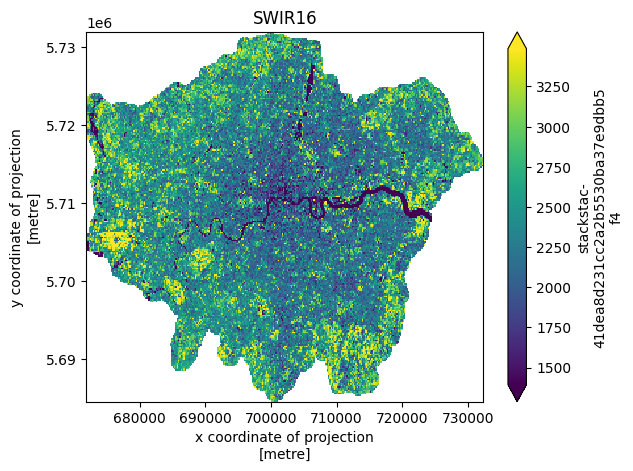

In [17]:
import matplotlib.pyplot as plt

swir16 = median_swir_2024.sel(band="swir1")
swir16.plot.imshow(cmap="viridis", robust=True)

plt.title("SWIR16")
plt.show()

In [39]:
client.shutdown()

In [4]:
import pystac
import pystac_client
import rioxarray as rio
from pydantic import BaseModel, HttpUrl

stac_client = pystac_client.Client.open(
    "https://earth-search.aws.element84.com/v1"
)  # Convert HttpUrl to string

search = stac_client.search(
    collections=["sentinel-2-l2a"],
    bbox=[-2.083282, 54.810974, -1.104813, 55.108230],
    datetime="2017-06-01/2017-08-31",
    query={"eo:cloud_cover": {"lt": 10}},  # Pass the custom query directly
)

In [5]:
items = list(search.get_items())

In [6]:
items

[<Item id=S2B_30UXG_20170815_0_L2A>, <Item id=S2B_30UWG_20170815_0_L2A>]

In [10]:
def select_best_item(
    search_results: pystac_client.item_search.ItemSearch,
) -> pystac.item.Item:
    """Select the STAC item with the least cloud cover."""
    return min(
        search_results.items(), key=lambda item: item.properties["eo:cloud_cover"]
    )

select_best_item(search)

<Item id=S2B_30UXG_20170815_0_L2A>

In [ ]:


# Download and Process EO Data
def download_eo_data(dataset: EODatasetConfig, raw_data_dir: Path) -> Dict[str, Any]:
    """Handler for downloading and processing EO data using STAC API."""
    stac_client = pystac_client.Client.open(
        str(dataset.file_config.url)
    )  # Convert HttpUrl to string

    # Perform STAC search with custom query
    search = stac_client.search(
        collections=dataset.file_config.collections,
        bbox=dataset.file_config.bbox,
        datetime=dataset.file_config.datetime,
        query=dataset.file_config.query,  # Pass the custom query directly
    )

    items = list(search.get_items())
    if not items:
        msg = f"No items found for bbox: {dataset.file_config.bbox} and datetime: {dataset.file_config.datetime}"
        raise ValueError(msg)

    best_item = select_best_item(search)

In [225]:

hsv_img = cv2.cvtColor(rgb_np, cv2.COLOR_RGB2HSV)
features = np.concatenate([rgb_np, hsv_img], axis=-1)

In [ ]:


# Convert RGB to HSV


# Stack RGB and HSV
features = np.concatenate([img, hsv_img], axis=-1)

<Axes: title={'center': 'band = 1, spatial_ref = 0'}, xlabel='x', ylabel='y'>

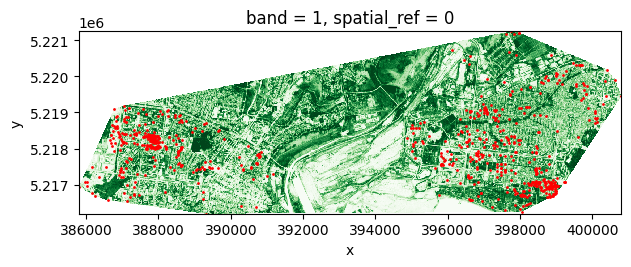

In [205]:
fig, ax = plt.subplots(figsize=(7, 7))

ndvi.plot(robust=True, ax=ax, cmap="Greens", add_colorbar=False)
mariupol.plot(ax=ax, color="red", markersize=1)

In [7]:
import multiprocessing
import multiprocessing.popen_spawn_posix

import threading

from dask.distributed import Client, LocalCluster, Lock



In [ ]:
threading.Lock()

In [92]:
xds = rio.open_rasterio(
    red_url,
    chunks=True,
    lock=False,
)

In [93]:
from pyproj import CRS

# Check the coordinate system
CRS(xds.rio.crs)

<Projected CRS: EPSG:32637>
Name: WGS 84 / UTM zone 37N
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: UTM zone 37N
- method: Transverse Mercator
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [94]:
mariupol_convex = mariupol_convex.to_crs(xds.rio.crs)
mariupol = mariupol.to_crs(xds.rio.crs)
clipped = xds.rio.clip(mariupol_convex.geometry, all_touched=True)

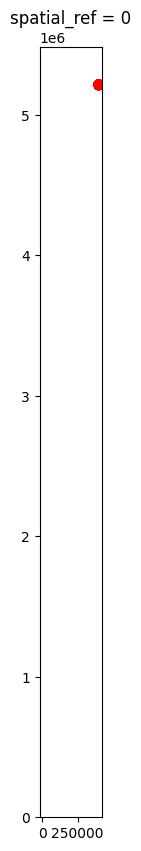

In [84]:
fig, ax = plt.subplots(figsize=(10, 10))
clipped.plot(ax=ax, alpha=0.6)

mariupol_convex.plot(ax=ax, fc="none", ec="red", linewidth=2)
mariupol.plot(ax=ax, ec="face", fc="red")
plt.show()

In [58]:
cell_size = raster.rio.resolution()

# Print the resolution (cell size)
print("Cell size (resolution):", cell_size)


Cell size (resolution): (10.0, -10.0)


In [ ]:
clipped.to_raster(Paths.RAW_DATA_DIR / "geospatial" / "eo" / "red.tif")

In [9]:
xds.rio.to_raster(
    Paths.RAW_DATA_DIR / "geospatial" / "eo" / "red.tif",
    tiled=True,
    lock=threading.Lock(),
)

In [ ]:

xds.rio.to_raster(
    "dask_thread.tif", tiled=True, lock=threading.Lock(),
)

In [13]:
pre_migration_url = items[0].assets["red"].href  # Example: Red band
post_migration_url = items[-1].assets["red"].href  # Example: Red band
pre_migration_url

'https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/T/CN/2024/3/S2A_37TCN_20240308_0_L2A/B04.tif'

In [ ]:
src = rasterio.open(pre_migration_url)

AttributeError: 'DatasetReader' object has no attribute 'bands'

In [ ]:
from matplotlib import pyplot

pyplot.imshow(array, cmap="pink")
<matplotlib.image.AxesImage object at 0x...>
pyplot.show()

In [15]:
src

<open DatasetReader name='https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/T/CN/2024/3/S2A_37TCN_20240308_0_L2A/B04.tif' mode='r'>

In [ ]:

    img = src.read([1, 2, 3])  # Assuming bands 1,2,3 are R,G,B
    img = np.moveaxis(img, 0, -1)  # Change to HxWxC

In [16]:
items

[<Item id=S2A_37TCN_20240308_0_L2A>,
 <Item id=S2A_37TCN_20240227_0_L2A>,
 <Item id=S2A_37TDN_20240227_0_L2A>,
 <Item id=S2B_37TCN_20231114_0_L2A>,
 <Item id=S2B_37TDN_20231114_0_L2A>,
 <Item id=S2B_37TCN_20231015_0_L2A>,
 <Item id=S2B_37TDN_20231015_0_L2A>,
 <Item id=S2B_37TCN_20231005_0_L2A>,
 <Item id=S2A_37TCN_20230930_0_L2A>,
 <Item id=S2A_37TDN_20230930_0_L2A>,
 <Item id=S2B_37TCN_20230925_0_L2A>,
 <Item id=S2B_37TDN_20230925_0_L2A>,
 <Item id=S2A_37TCN_20230920_0_L2A>,
 <Item id=S2A_37TDN_20230920_0_L2A>,
 <Item id=S2A_37TDN_20230831_0_L2A>,
 <Item id=S2A_37TDN_20230821_0_L2A>,
 <Item id=S2B_37TCN_20230816_0_L2A>,
 <Item id=S2B_37TCN_20230806_0_L2A>,
 <Item id=S2B_37TDN_20230806_0_L2A>,
 <Item id=S2B_37TCN_20230727_0_L2A>,
 <Item id=S2B_37TDN_20230727_0_L2A>,
 <Item id=S2B_37TCN_20230707_0_L2A>,
 <Item id=S2B_37TDN_20230707_0_L2A>,
 <Item id=S2A_37TCN_20230622_0_L2A>,
 <Item id=S2A_37TDN_20230622_0_L2A>,
 <Item id=S2B_37TCN_20230518_0_L2A>,
 <Item id=S2B_37TDN_20230518_0_L2A>,
 

In [65]:
# Function to extract RGB and HSV features from an image
def extract_features(image_path):
    with rasterio.open(image_path) as src:
        img = src.read([1])  # Assuming bands 1,2,3 are R,G,B
        img = np.moveaxis(img, 0, -1)  # Change to HxWxC

    # Convert RGB to HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Stack RGB and HSV
    features = np.concatenate([img, hsv_img], axis=-1)
    return features

pre_migration_img = extract_features(pre_migration_url)
post_migration_img = extract_features(post_migration_url)

IndexError: band index 2 out of range (not in (1,))

In [ ]:




# Load pre- and post-migration images


# Compute difference
feature_diff = post_migration_img - pre_migration_img

# Flatten for model training
X = feature_diff.reshape(-1, 6)  # 6 channels (RGB + HSV differences)
y = np.load("labels.npy")  # Load manually labeled data

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean():.2f}")

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# Apply model to full image
y_full_pred = model.predict(X)
mask = y_full_pred.reshape(pre_migration_img.shape[:2])

# Apply median filter
mask_smoothed = cv2.medianBlur(mask.astype(np.uint8), 5)

# Convert mask to vector format using GDAL
output_raster = "tent_predictions.tif"
driver = gdal.GetDriverByName("GTiff")
dataset = driver.Create(output_raster, mask.shape[1], mask.shape[0], 1, gdal.GDT_Byte)
dataset.GetRasterBand(1).WriteArray(mask_smoothed)
dataset.FlushCache()

# Convert raster to vector
vector_output = "tent_predictions.geojson"
gdal.VectorTranslate(vector_output, output_raster, format="GeoJSON")

# Load and clean up vector data
vector_data = gpd.read_file(vector_output)
vector_data = vector_data.simplify(tolerance=0.1)
vector_data.to_file("tent_predictions_clean.geojson", driver="GeoJSON")

print("Processing complete. Results saved as tent_predictions_clean.geojson")
